# Part 1: Dataset Collection and Preparation 

>Dataset Import Code

In [1]:
import pandas as pd
df = pd.read_csv("netflix_titles.csv")

>Display First Five Rows

In [2]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


>Dataset Shape

In [3]:
df.shape

(8807, 12)

>Checking Missing Values

In [4]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

>Removing Duplicate Records

In [5]:
df.drop_duplicates(inplace=True)

>Handling Missing Data

In [6]:
df.fillna("Unknown", inplace=True)

>Converting Date Format

In [10]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

>Checking Data Types

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      8807 non-null   object
 4   cast          8807 non-null   object
 5   country       8807 non-null   object
 6   date_added    8807 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8807 non-null   object
 9   duration      8807 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


# Part 2: Exploratory Data Analysis (EDA) 

>Statistical Analysis

In [9]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


>Correlation Heatmap

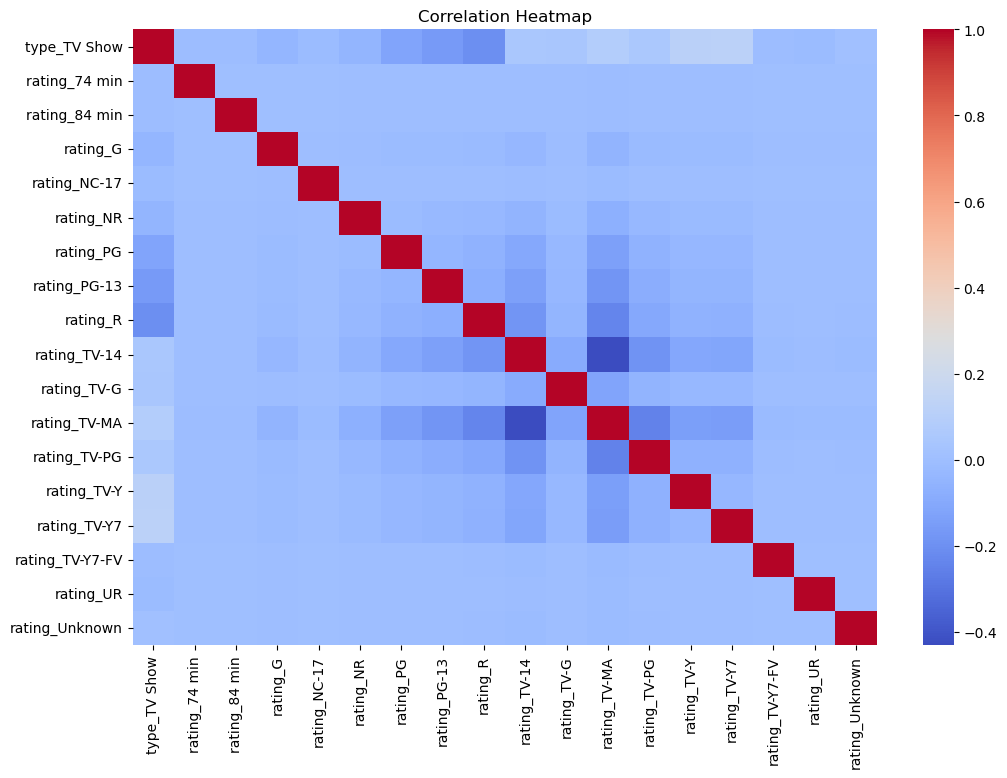

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create dummy variables
heatmap_data = pd.get_dummies(df[['type', 'rating']], drop_first=True)

# Correlation matrix
corr_matrix = heatmap_data.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

>Pair Plot

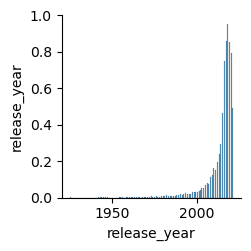

In [12]:
sns.pairplot(df)
plt.show()

>Summary Statistics Table

In [13]:
df.describe()

,date_added,release_year
count,8709,8807.000000
mean,2019-05-23 01:45:29.452290816,2014.180198
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-20 00:00:00,2013.000000
50%,2019-07-12 00:00:00,2017.000000
75%,2020-08-26 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.819312


# Part 3: Categorical Data Visualization

>Bar Chart

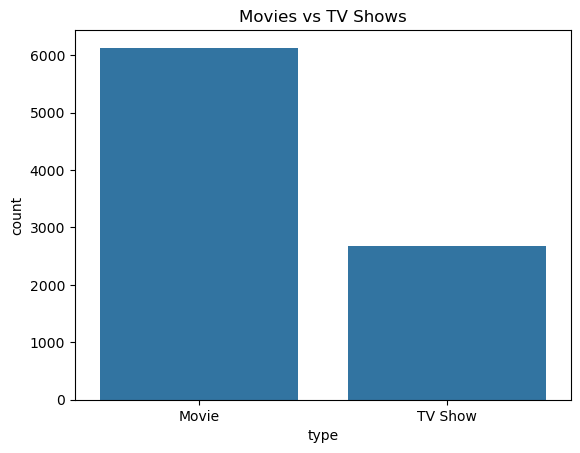

In [14]:
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

>Pie Chart

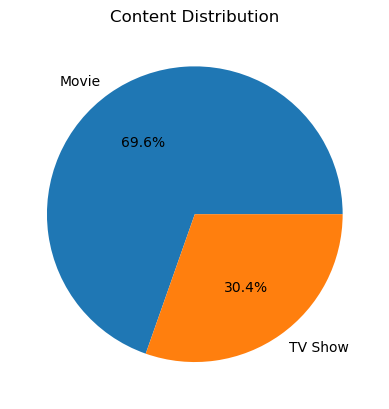

In [15]:
df['type'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Content Distribution")
plt.ylabel("")
plt.show()

>Count Plot

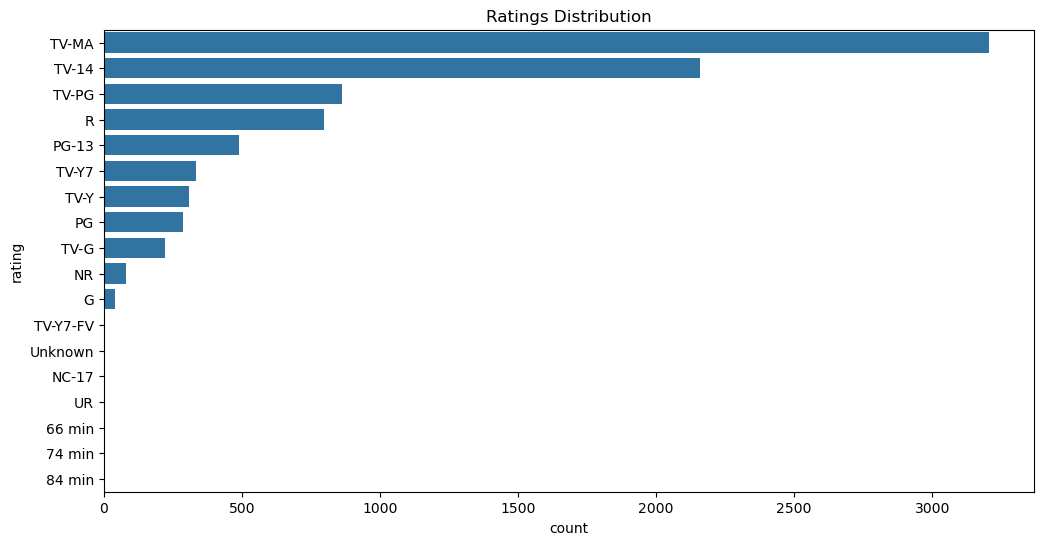

In [16]:
plt.figure(figsize=(12,6))
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)
plt.title("Ratings Distribution")
plt.show()

>Stacked Bar Chart

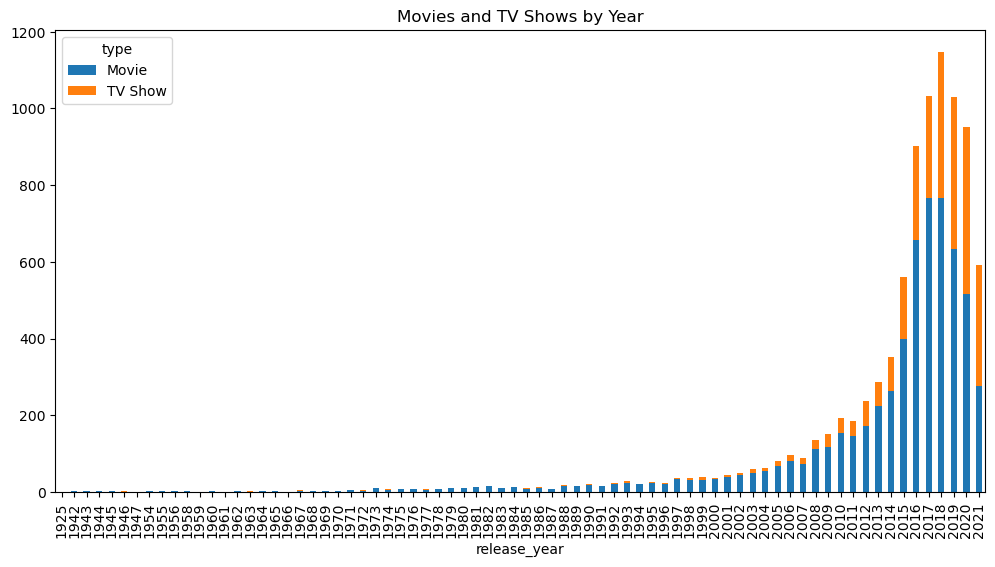

In [17]:
pd.crosstab(df['release_year'], df['type']).plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Movies and TV Shows by Year")
plt.show()

# Part 4: Numerical Data Visualization

>Histogram

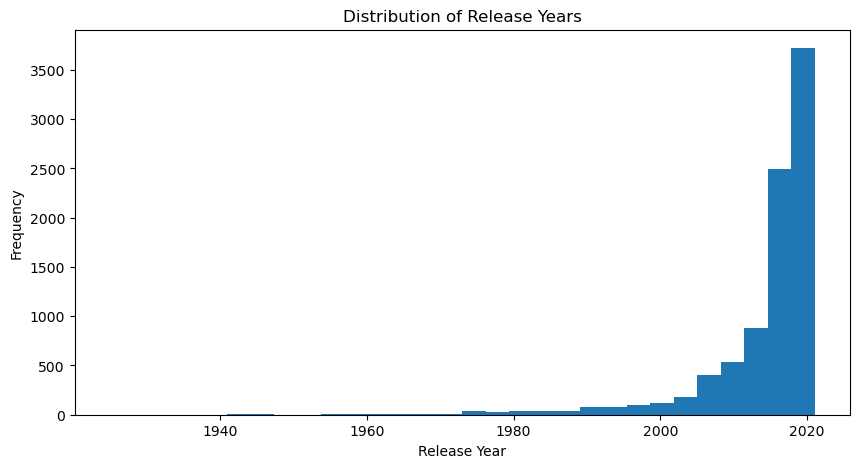

In [18]:
plt.figure(figsize=(10,5))
plt.hist(df['release_year'], bins=30)
plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()

>Box Plot

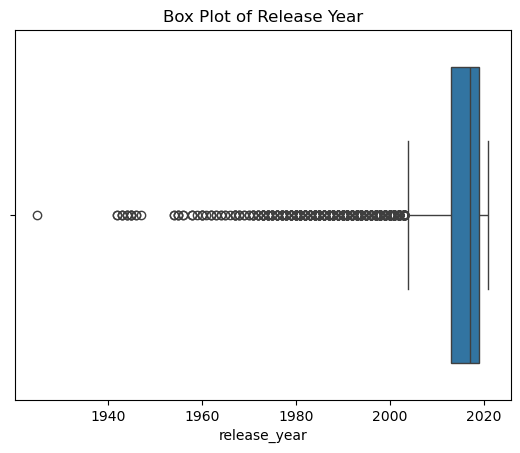

In [19]:
sns.boxplot(x=df['release_year'])
plt.title("Box Plot of Release Year")
plt.show()

>Scatter Plot

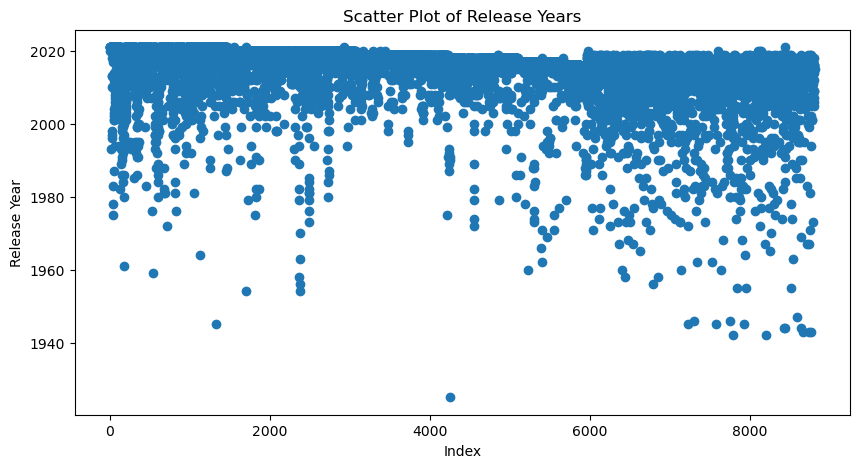

In [20]:
plt.figure(figsize=(10,5))
plt.scatter(df.index, df['release_year'])
plt.title("Scatter Plot of Release Years")
plt.xlabel("Index")
plt.ylabel("Release Year")
plt.show()

>Violin Plot

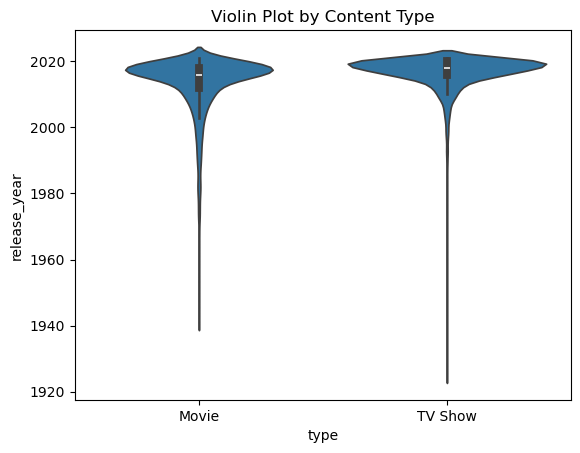

In [21]:
sns.violinplot(x='type', y='release_year', data=df)
plt.title("Violin Plot by Content Type")
plt.show()

# Part 5: Time-Series and Trend Visualization

>Line Graph

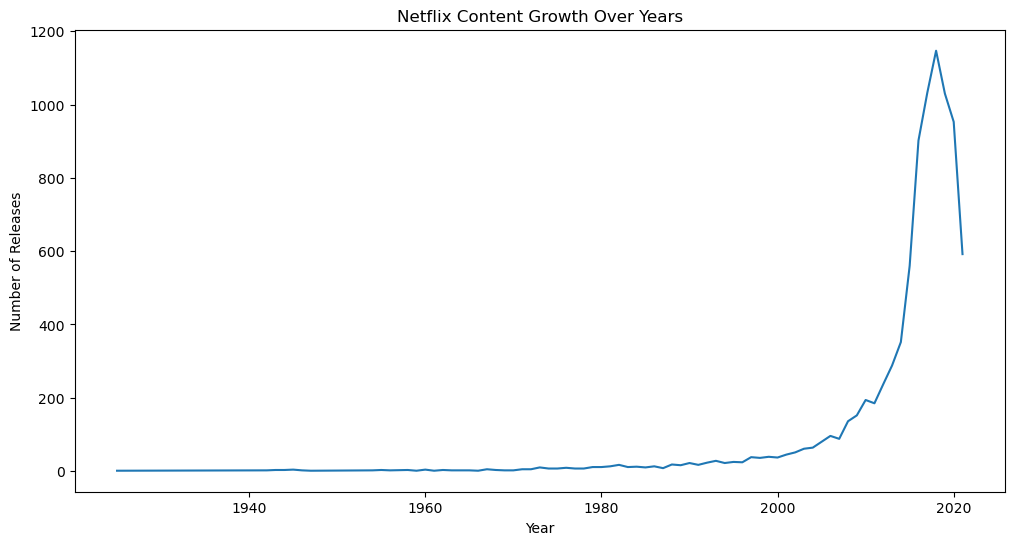

In [22]:
year_data = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.plot(year_data.index, year_data.values)
plt.title("Netflix Content Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Releases")
plt.show()

>Area Chart

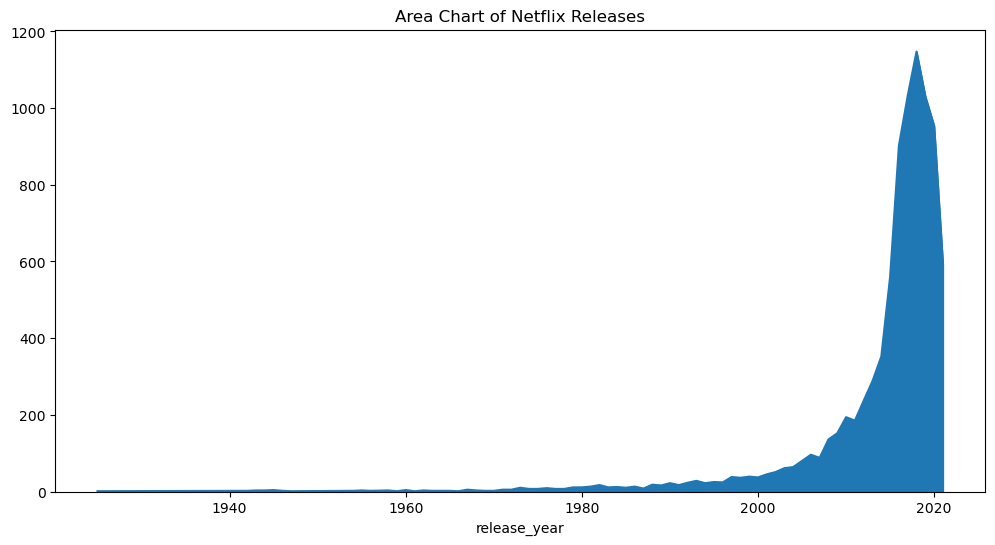

In [23]:
year_data.plot.area(figsize=(12,6))
plt.title("Area Chart of Netflix Releases")
plt.show()

>Moving Average Trend

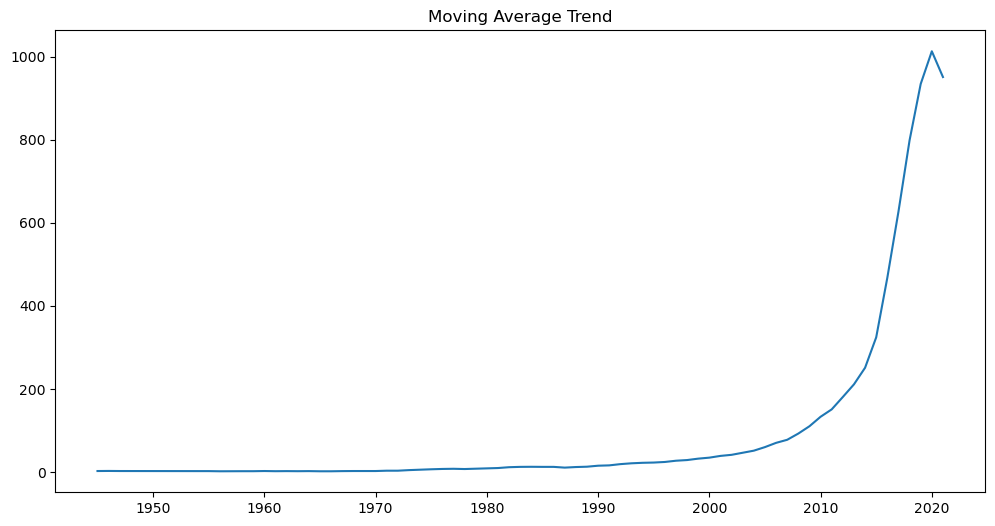

In [24]:
moving_avg = year_data.rolling(window=5).mean()

plt.figure(figsize=(12,6))
plt.plot(year_data.index, moving_avg)
plt.title("Moving Average Trend")
plt.show()

# Part 6: Advanced Visualization Techniques

>Tree Map

In [25]:
pip install squarify

Note: you may need to restart the kernel to use updated packages.


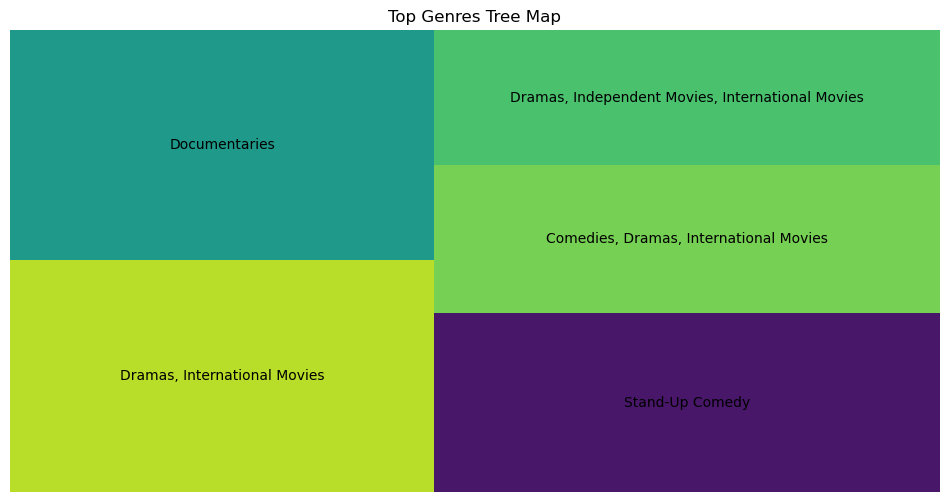

In [27]:
import squarify

genre = df['listed_in'].value_counts().head(5)

plt.figure(figsize=(12,6))
squarify.plot(sizes=genre.values, label=genre.index)
plt.title("Top Genres Tree Map")
plt.axis('off')
plt.show()